# DRG-Level Geographic Payment Comparison — Rural vs Urban
### DSCI 5260 — Group 6 | Medicare Inpatient Utilization and Payment Analysis

---

**Motivation:**

RQ1 EDA showed Rural hospitals have a significantly higher payment ratio (0.36–0.40)
compared to Metropolitan hospitals (0.12–0.20). However, RQ3 modeling found geography
to be near-zero in feature importance.

Before concluding that geography is irrelevant, two explanations must be tested:

1. **Case Mix Explanation** — Rural hospitals treat simpler, lower-weight diagnoses.
   Metropolitan hospitals treat complex cases that naturally bill more and get paid more.
   The EDA gap may just reflect *what* each region treats, not *how* Medicare pays them.

2. **Genuine Geographic Payment Difference** — Even for identical diagnoses, Medicare
   pays rural hospitals more per dollar billed due to policy adjustments (e.g. Critical
   Access Hospital designations, rural wage index policies).

**Analysis flow:**
- First establish case mix differences (DRG Weight by geography) — **before** any DRG comparison
- Then control for case mix by comparing the same DRG across geographies
- Then test whether the gap is statistically significant

**Research Question:**
> For identical diagnoses, does Medicare pay rural hospitals more generously than urban
> hospitals — or does the geographic payment gap disappear once case mix is controlled?

---
## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.stats import kruskal, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams['figure.dpi']       = 110
plt.rcParams['font.size']        = 10
plt.rcParams['axes.titlesize']   = 12
plt.rcParams['axes.titleweight'] = 'bold'

# ── Colour palette (consistent with EDA notebook) ─────────────────────────
BLUE   = '#1565C0'
ORANGE = '#EF6C00'
GREEN  = '#2E7D32'
GOLD   = '#F9A825'

RUCA_PALETTE = {'Metropolitan': BLUE, 'Micropolitan': ORANGE,
                'Small Town': GOLD, 'Rural': GREEN}
RUCA_ORDER   = ['Metropolitan', 'Micropolitan', 'Small Town', 'Rural']
RUCA_COLORS  = [BLUE, ORANGE, GOLD, GREEN]

In [2]:
BASE_DIR      = Path('..')
PROCESSED_DIR = BASE_DIR / 'Data' / 'Processed_Data'

df = pd.read_parquet(PROCESSED_DIR / 'df_medidata.parquet')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Years : {sorted(df["Data_Year"].unique())}')
print(f'States: {df["Rndrng_Prvdr_State_Abrvtn"].nunique()} unique')

Loaded: 1,178,407 rows x 20 columns
Years : [2017, 2018, 2019, 2020, 2021, 2022, 2023]
States: 51 unique


In [3]:
# ── Ensure all derived features exist ─────────────────────────────────────
if 'Payment_Gap' not in df.columns:
    df['Payment_Gap'] = df['Avg_Submtd_Cvrd_Chrg'] - df['Avg_Mdcr_Pymt_Amt']

if 'Payment_Ratio' not in df.columns:
    df['Payment_Ratio'] = df['Avg_Mdcr_Pymt_Amt'] / df['Avg_Submtd_Cvrd_Chrg']

if 'payment_gap_per_discharge' not in df.columns:
    df['payment_gap_per_discharge'] = df['Payment_Gap'] / df['Tot_Dschrgs']

# ── RUCA grouping ──────────────────────────────────────────────────────────
def map_ruca_group(v):
    if pd.isna(v) or v == 99.0:          return 'Unknown'
    if v in [1.0,1.1,2.0,2.1,3.0]:      return 'Metropolitan'
    if v in [4.0,4.1,5.0,6.0]:          return 'Micropolitan'
    if v in [7.0,7.1,7.2,8.0,8.2,9.0]:  return 'Small Town'
    return 'Rural'

if 'RUCA_Group' not in df.columns:
    df['RUCA_Group'] = df['Rndrng_Prvdr_RUCA'].apply(map_ruca_group)

# ── Working subset — exclude Unknown RUCA ─────────────────────────────────
df_geo = df[df['RUCA_Group'] != 'Unknown'].copy()

print('Feature check complete.')
print(f'  Records after RUCA filter: {len(df_geo):,}')
print(f'\nRUCA Group distribution:')
print(df_geo['RUCA_Group'].value_counts())

Feature check complete.
  Records after RUCA filter: 1,172,668

RUCA Group distribution:
RUCA_Group
Metropolitan    1045269
Micropolitan     104963
Small Town        18606
Rural              3830
Name: count, dtype: int64


## Rural has only 3,830 records — 0.3% of the data

---
## 2. Case Mix Comparison — Do Metro and Rural Treat Different Complexity Cases?

Before comparing payment ratios for specific DRGs, we want to find out whether
Metropolitan and Rural hospitals treat systematically different types of cases.

**DRG Weight** is the CMS measure of diagnosis complexity — higher weight = more
complex, more resource-intensive case. If Metropolitan hospitals treat significantly
higher-weight cases than Rural hospitals across the full dataset, that alone explains
a large part of the payment ratio difference seen in EDA.

This analysis uses the **full dataset** — all 634 DRGs, all records — to capture
the true case mix each region handles.

In [14]:
# ── Case mix summary: median and mean DRG Weight by RUCA ──────────────────
casemix = (
    df_geo[df_geo['RUCA_Group'].isin(RUCA_ORDER)]
    .groupby('RUCA_Group')['DRG_Weight']
    .agg(['mean', 'median', 'std', 'count'])
    .reindex(RUCA_ORDER)
    .round(4)
)
casemix.columns = ['Mean Weight', 'Median Weight', 'Std Weight', 'Records']

print('=== DRG Weight (Case Mix) by RUCA Group — Full Dataset ===')
print(casemix.to_string())
print(f'\nMetropolitan vs Rural mean weight difference: '
      f'{casemix.loc["Metropolitan","Mean Weight"] - casemix.loc["Rural","Mean Weight"]:.4f}')
print(f'Metropolitan treats cases {casemix.loc["Metropolitan","Mean Weight"] / casemix.loc["Rural","Mean Weight"]:.2f}x '
      f'more complex than Rural on average')

=== DRG Weight (Case Mix) by RUCA Group — Full Dataset ===
              Mean Weight  Median Weight  Std Weight  Records
RUCA_Group                                                   
Metropolitan       1.9699         1.4112      1.8480  1045269
Micropolitan       1.5332         1.2070      1.0868   104963
Small Town         1.3521         1.1440      0.8724    18606
Rural              1.3288         1.1116      0.8320     3830

Metropolitan vs Rural mean weight difference: 0.6411
Metropolitan treats cases 1.48x more complex than Rural on average


### Metropolitan mean weight / Rural mean weight = 1.97 / 1.33 = 1.48

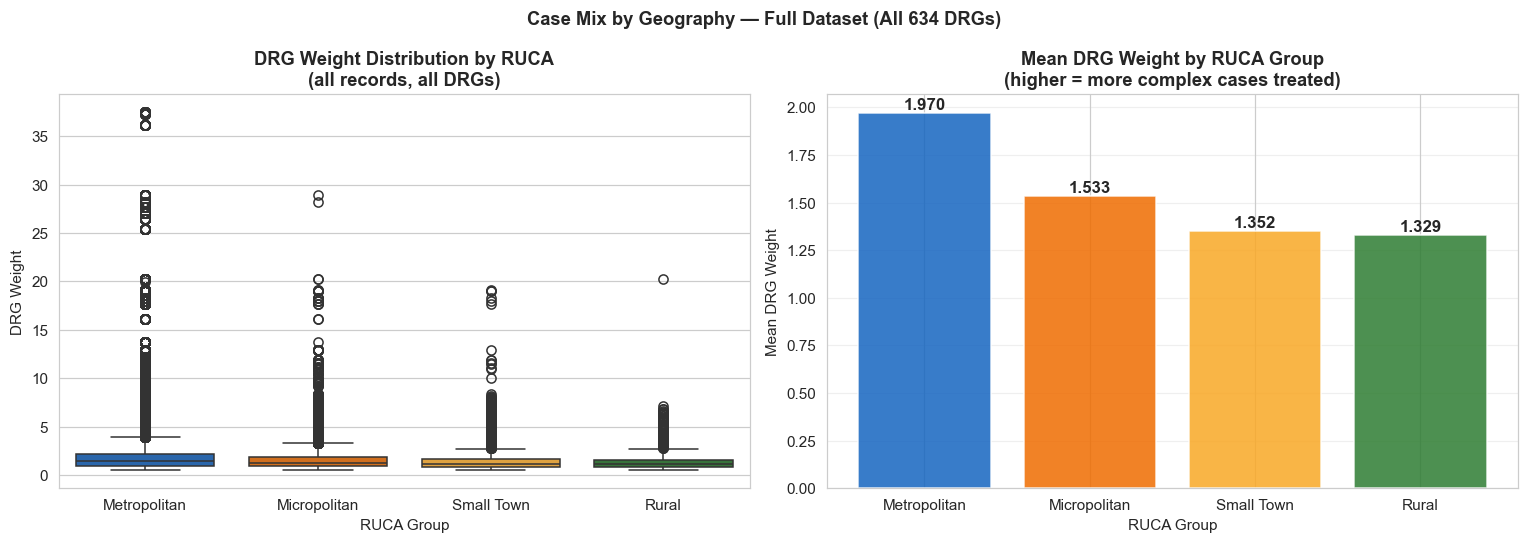

In [5]:
# ── Visualize case mix difference ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Case Mix by Geography — Full Dataset (All 634 DRGs)',
             fontweight='bold')

# Box plot — spread of DRG weights
sns.boxplot(
    data=df_geo[df_geo['RUCA_Group'].isin(RUCA_ORDER)],
    x='RUCA_Group', y='DRG_Weight',
    order=RUCA_ORDER, palette=RUCA_PALETTE, ax=axes[0]
)
axes[0].set_title('DRG Weight Distribution by RUCA\n(all records, all DRGs)')
axes[0].set_xlabel('RUCA Group')
axes[0].set_ylabel('DRG Weight')

# Bar chart — mean DRG weight
mean_wt = casemix['Mean Weight']
bars = axes[1].bar(RUCA_ORDER, mean_wt.values, color=RUCA_COLORS, alpha=0.85)
for bar, v in zip(bars, mean_wt.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + 0.02, f'{v:.3f}',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Mean DRG Weight by RUCA Group\n(higher = more complex cases treated)')
axes[1].set_xlabel('RUCA Group')
axes[1].set_ylabel('Mean DRG Weight')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# ── Median DRG Weight per RUCA for the 39 common DRGs ────────────────────
# This will be computed after identifying common DRGs in Section 3
# Run this cell AFTER Section 3 cell has been executed

# First identify common DRGs (preview — full logic in Section 3)
drg_ruca_counts = (
    df_geo.groupby(['DRG_Cd', 'DRG_Desc', 'RUCA_Group'])
    .agg(hospital_count=('Rndrng_Prvdr_CCN', 'nunique'))
    .reset_index()
)
drg_pivot = drg_ruca_counts.pivot_table(
    index=['DRG_Cd', 'DRG_Desc'],
    columns='RUCA_Group',
    values='hospital_count'
).fillna(0).reset_index()

MIN_HOSPITALS = 10
common_drgs = drg_pivot[
    (drg_pivot.get('Metropolitan', 0) >= MIN_HOSPITALS) &
    (drg_pivot.get('Micropolitan', 0) >= MIN_HOSPITALS) &
    (drg_pivot.get('Small Town',   0) >= MIN_HOSPITALS) &
    (drg_pivot.get('Rural',        0) >= MIN_HOSPITALS)
]['DRG_Cd'].tolist()

common_df = df_geo[df_geo['DRG_Cd'].isin(common_drgs)].copy()

# ── Now compute median DRG Weight for common DRGs by RUCA ─────────────────
casemix_common = (
    common_df[common_df['RUCA_Group'].isin(RUCA_ORDER)]
    .groupby('RUCA_Group')['DRG_Weight']
    .agg(['mean', 'median'])
    .reindex(RUCA_ORDER)
    .round(4)
)
casemix_common.columns = ['Mean Weight', 'Median Weight']

print('=== DRG Weight for the 39 Common DRGs Only ===')
print(casemix_common.to_string())
print()
print('=== DRG Weight — Full Dataset (all 634 DRGs) ===')
print(casemix[['Mean Weight', 'Median Weight']].to_string())
print()
print('Key question: Does the weight gap between Metro and Rural shrink')
print('when we restrict to the 39 common DRGs?')
print('If yes → the 39 DRGs are a fair, lower-complexity comparison set.')
print('If no  → even within common DRGs, Metro treats harder cases.')

=== DRG Weight for the 39 Common DRGs Only ===
              Mean Weight  Median Weight
RUCA_Group                              
Metropolitan       1.3243         1.0855
Micropolitan       1.3011         1.1186
Small Town         1.2352         1.0855
Rural              1.2023         1.0529

=== DRG Weight — Full Dataset (all 634 DRGs) ===
              Mean Weight  Median Weight
RUCA_Group                              
Metropolitan       1.9699         1.4112
Micropolitan       1.5332         1.2070
Small Town         1.3521         1.1440
Rural              1.3288         1.1116

Key question: Does the weight gap between Metro and Rural shrink
when we restrict to the 39 common DRGs?
If yes → the 39 DRGs are a fair, lower-complexity comparison set.
If no  → even within common DRGs, Metro treats harder cases.


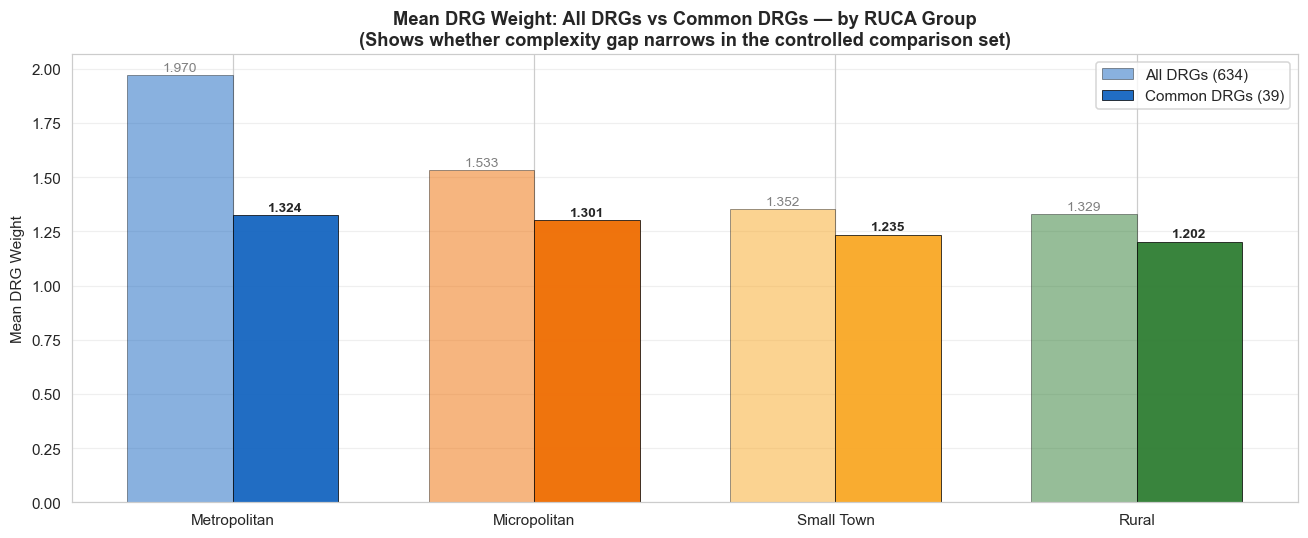

In [7]:
# ── Side-by-side: Full dataset vs Common DRGs — mean weight comparison ────
fig, ax = plt.subplots(figsize=(12, 5))

x     = np.arange(len(RUCA_ORDER))
width = 0.35

bars1 = ax.bar(x - width/2, casemix['Mean Weight'].values,
               width=width, color=RUCA_COLORS, alpha=0.5,
               label='All DRGs (634)', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, casemix_common['Mean Weight'].values,
               width=width, color=RUCA_COLORS, alpha=0.95,
               label='Common DRGs (39)', edgecolor='black', linewidth=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, color='grey')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(RUCA_ORDER)
ax.set_ylabel('Mean DRG Weight')
ax.set_title('Mean DRG Weight: All DRGs vs Common DRGs — by RUCA Group\n'
             '(Shows whether complexity gap narrows in the controlled comparison set)',
             fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Key findings:**
- Metropolitan areas have the highest complexity gap — All DRGs average 1.970 vs. Common DRGs at 1.324, a difference of 0.646.
- Micropolitan, Small Town, and Rural regions show much smaller gaps (roughly 0.13–0.23), indicating their DRG mix is inherently less complex.
- When restricted to the common DRG set, complexity scores converge across all four regions (range: 1.202–1.324), narrowing the urban–rural divide significantly.

**What this means for the Medicare analysis:**
- The narrowing gap under controlled comparison suggests that much of the observed urban–rural payment variation is driven by DRG mix differences, not purely by location 
**It's because urban hospitals simply treat more high-complexity cases that rural hospitals never see.**

---
## 3. Find DRGs Treated Across All Geographic Groups

Now that we have established case mix differences, we identify which DRGs are treated
by a minimum number of hospitals in **every** RUCA group. These become our controlled
comparison set — the same diagnosis, across all geographies.

Note: Rural hospitals have only ~3,830 records total across 7 years. This severely
limits how many DRGs qualify — only **routine, high-volume diagnoses** appear in
sufficient numbers across all regions.

In [8]:
# common_drgs and common_df already computed in Section 2 above
# This cell confirms and summarizes the common DRG set

print(f'Total unique DRGs in dataset : {df_geo["DRG_Cd"].nunique()}')
print(f'DRGs treated across all RUCA : {len(common_drgs)}')
print(f'Coverage                     : {len(common_drgs)/df_geo["DRG_Cd"].nunique()*100:.1f}% of all DRGs')
print(f'\nRecords in common DRG set    : {len(common_df):,}')
print(f'Records in full dataset      : {len(df_geo):,}')
print()

# Show DRG weight range for the 39 common DRGs
common_drg_weights = (
    common_df.groupby(['DRG_Cd', 'DRG_Desc'])['DRG_Weight']
    .median()
    .reset_index()
    .rename(columns={'DRG_Weight': 'Median_DRG_Weight'})
    .sort_values('Median_DRG_Weight', ascending=False)
)

print('=== All 39 Common DRGs — Sorted by Complexity (DRG Weight) ===')
print(common_drg_weights[['DRG_Desc', 'Median_DRG_Weight']].to_string(index=False))
print(f'\nWeight range: {common_drg_weights["Median_DRG_Weight"].min():.3f} '
      f'to {common_drg_weights["Median_DRG_Weight"].max():.3f}')
print('All 39 are routine/common diagnoses — not complex surgical or specialty cases.')

Total unique DRGs in dataset : 634
DRGs treated across all RUCA : 39
Coverage                     : 6.2% of all DRGs

Records in common DRG set    : 480,680
Records in full dataset      : 1,172,668

=== All 39 Common DRGs — Sorted by Complexity (DRG Weight) ===
                                                                             DRG_Desc  Median_DRG_Weight
                      INFECTIOUS AND PARASITIC DISEASES WITH O.R. PROCEDURES WITH MCC             5.0571
                                       MAJOR SMALL AND LARGE BOWEL PROCEDURES WITH CC             2.5268
                      RESPIRATORY SYSTEM DIAGNOSIS WITH VENTILATOR SUPPORT <=96 HOURS             2.4841
                                  HIP AND FEMUR PROCEDURES EXCEPT MAJOR JOINT WITH CC             2.0878
  MAJOR HIP AND KNEE JOINT REPLACEMENT OR REATTACHMENT OF LOWER EXTREMITY WITHOUT MCC             1.9898
                            SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITH MCC             1.8663
   

---
## 4. Compare Payment Ratio for Same DRG Across RUCA Groups

With case mix established and common DRGs identified, we now compare payment ratios
for **identical diagnoses** across geographies.

The key column is `Rural_vs_Metro`:
- **Positive** → Rural gets paid more per dollar billed than Metropolitan for that DRG
- **Near zero** → Geography makes no difference for that DRG
- **Negative** → Metropolitan gets paid more (would be surprising)

In [9]:
# ── Aggregate payment ratio by DRG + RUCA ─────────────────────────────────
drg_ruca_ratio = (
    common_df
    .groupby(['DRG_Cd', 'DRG_Desc', 'RUCA_Group'])
    .agg(
        median_ratio   = ('Payment_Ratio',    'median'),
        median_payment = ('Avg_Mdcr_Pymt_Amt','median'),
        median_gap     = ('Payment_Gap',       'median'),
        record_count   = ('Rndrng_Prvdr_CCN',  'count')
    )
    .reset_index()
)

# ── Pivot for Rural vs Metropolitan comparison ────────────────────────────
ratio_pivot = drg_ruca_ratio.pivot_table(
    index=['DRG_Cd', 'DRG_Desc'],
    columns='RUCA_Group',
    values='median_ratio'
).reset_index()

# Merge in DRG Weight for context
ratio_pivot = ratio_pivot.merge(
    common_drg_weights[['DRG_Cd', 'Median_DRG_Weight']],
    on='DRG_Cd'
)

ratio_pivot['Rural_vs_Metro'] = ratio_pivot['Rural'] - ratio_pivot['Metropolitan']
ratio_pivot = ratio_pivot.sort_values('Rural_vs_Metro', ascending=False)

# ── Show full table with DRG Weight included ──────────────────────────────
print('=== All 39 Common DRGs: Payment Ratio by Geography + DRG Weight ===')
print(ratio_pivot[['DRG_Desc', 'Median_DRG_Weight',
                   'Metropolitan', 'Rural', 'Rural_vs_Metro']]
      .to_string(index=False))

print(f'\n=== Overall Direction ===')
rural_higher = (ratio_pivot['Rural_vs_Metro'] > 0).sum()
metro_higher = (ratio_pivot['Rural_vs_Metro'] < 0).sum()
equal        = (ratio_pivot['Rural_vs_Metro'] == 0).sum()
print(f'DRGs where Rural ratio > Metropolitan : {rural_higher} / {len(ratio_pivot)}')
print(f'DRGs where Metropolitan ratio > Rural : {metro_higher} / {len(ratio_pivot)}')
print(f'DRGs where ratio is equal             : {equal} / {len(ratio_pivot)}')

=== All 39 Common DRGs: Payment Ratio by Geography + DRG Weight ===
                                                                             DRG_Desc  Median_DRG_Weight  Metropolitan    Rural  Rural_vs_Metro
                      INFECTIOUS AND PARASITIC DISEASES WITH O.R. PROCEDURES WITH MCC             5.0571      0.221212 0.505369        0.284157
                            SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITH MCC             1.8663      0.206380 0.446011        0.239631
                                    RESPIRATORY INFECTIONS AND INFLAMMATIONS WITH MCC             1.8491      0.240496 0.471433        0.230936
                                    OTHER KIDNEY AND URINARY TRACT DIAGNOSES WITH MCC             1.6067      0.212795 0.439140        0.226345
                                                     HEART FAILURE AND SHOCK WITH MCC             1.3454      0.212383 0.435998        0.223615
                                                  GASTROINTESTINAL H

---
## 5. Visualize — Payment Ratio by Geography for Top 15 Common DRGs

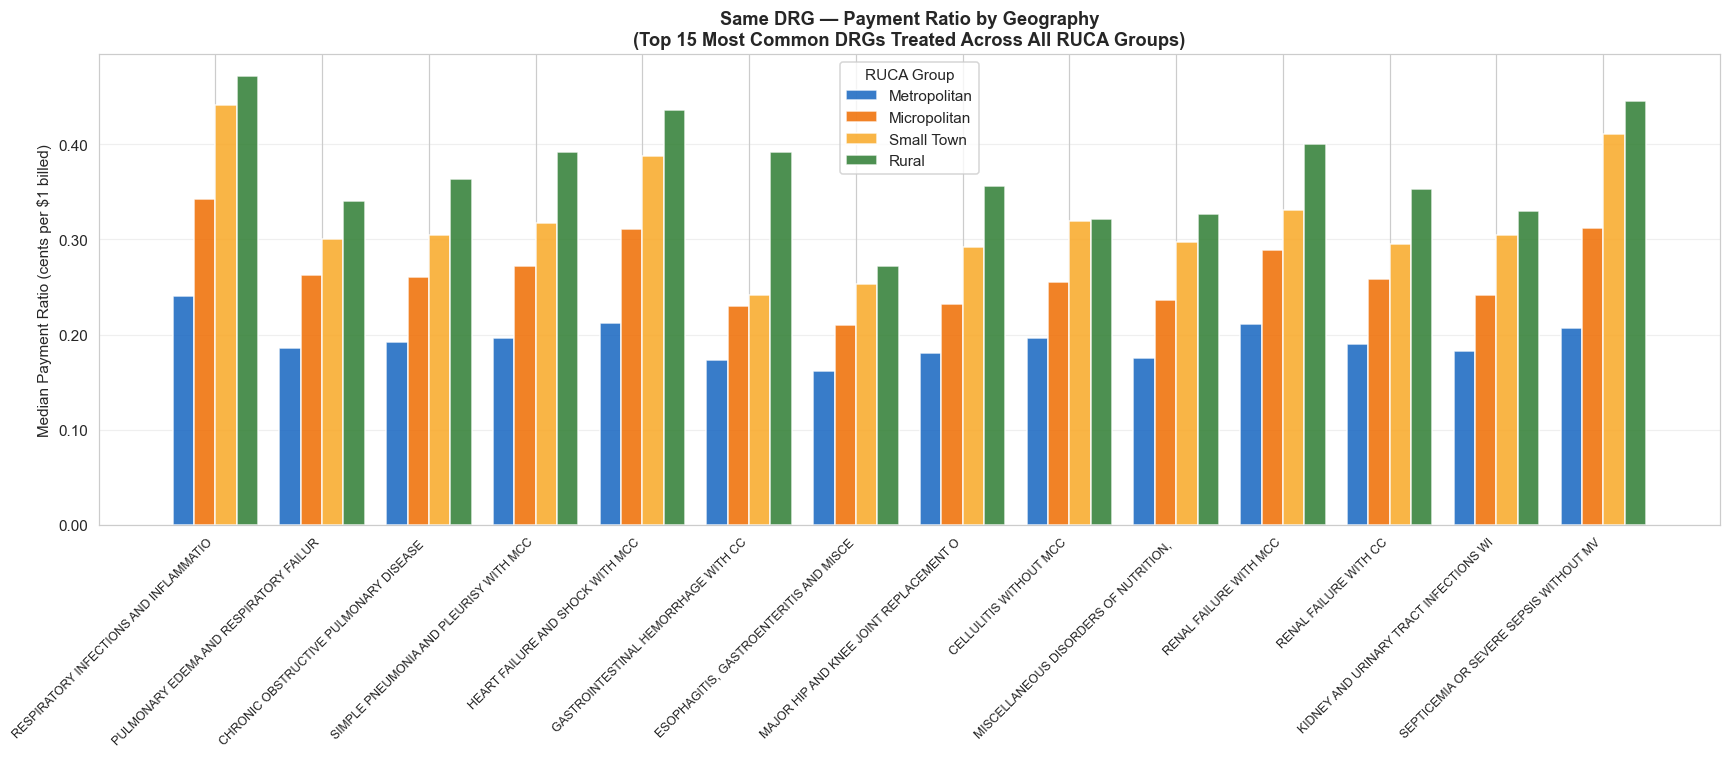

In [10]:
# ── Top 15 most common DRGs by record count ───────────────────────────────
top_common = (
    common_df.groupby('DRG_Cd')
    .size()
    .sort_values(ascending=False)
    .head(15)
    .index.tolist()
)

plot_df = drg_ruca_ratio[drg_ruca_ratio['DRG_Cd'].isin(top_common)].copy()
plot_df['DRG_Short'] = plot_df['DRG_Desc'].str[:38]

drgs  = plot_df['DRG_Short'].unique()
x     = np.arange(len(drgs))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 7))

for i, (ruca, color) in enumerate(zip(RUCA_ORDER, RUCA_COLORS)):
    vals = [
        plot_df[(plot_df['DRG_Short'] == d) &
                (plot_df['RUCA_Group'] == ruca)]['median_ratio'].values
        for d in drgs
    ]
    vals = [v[0] if len(v) > 0 else np.nan for v in vals]
    ax.bar([xi + i * width for xi in x], vals,
           width=width, label=ruca, color=color, alpha=0.85)

ax.set_xticks([xi + width * 1.5 for xi in x])
ax.set_xticklabels(drgs, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Median Payment Ratio (cents per $1 billed)')
ax.set_title(
    'Same DRG — Payment Ratio by Geography\n'
    '(Top 15 Most Common DRGs Treated Across All RUCA Groups)',
    fontweight='bold'
)
ax.legend(title='RUCA Group')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.2f}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Distribution of Rural vs Metro Gap Across All 39 Common DRGs

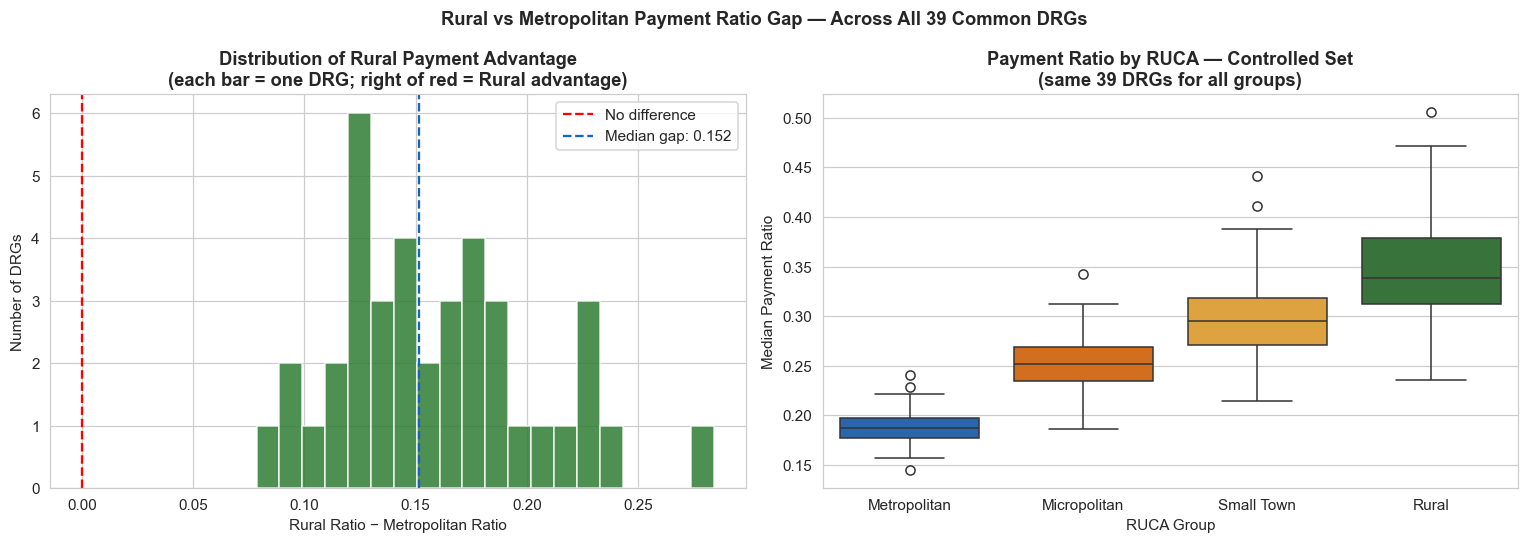

Median Rural_vs_Metro gap : 0.1518
Mean   Rural_vs_Metro gap : 0.1596

Rural gets paid more per dollar for EVERY common DRG compared to Metropolitan.
The geographic payment difference is NOT eliminated by controlling for diagnosis.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rural vs Metropolitan Payment Ratio Gap — Across All 39 Common DRGs',
             fontweight='bold')

# Histogram of Rural advantage
axes[0].hist(ratio_pivot['Rural_vs_Metro'].dropna(),
             bins=20, color=GREEN, edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--',
                linewidth=1.5, label='No difference')
axes[0].axvline(ratio_pivot['Rural_vs_Metro'].median(),
                color=BLUE, linestyle='--', linewidth=1.5,
                label=f'Median gap: {ratio_pivot["Rural_vs_Metro"].median():.3f}')
axes[0].set_xlabel('Rural Ratio − Metropolitan Ratio')
axes[0].set_ylabel('Number of DRGs')
axes[0].set_title('Distribution of Rural Payment Advantage\n'
                  '(each bar = one DRG; right of red = Rural advantage)')
axes[0].legend()

# Box plot
box_df = drg_ruca_ratio[drg_ruca_ratio['RUCA_Group'].isin(RUCA_ORDER)].copy()
sns.boxplot(
    data=box_df, x='RUCA_Group', y='median_ratio',
    order=RUCA_ORDER, palette=RUCA_PALETTE, ax=axes[1]
)
axes[1].set_title('Payment Ratio by RUCA — Controlled Set\n'
                  '(same 39 DRGs for all groups)')
axes[1].set_xlabel('RUCA Group')
axes[1].set_ylabel('Median Payment Ratio')

plt.tight_layout()
plt.show()

print(f'Median Rural_vs_Metro gap : {ratio_pivot["Rural_vs_Metro"].median():.4f}')
print(f'Mean   Rural_vs_Metro gap : {ratio_pivot["Rural_vs_Metro"].mean():.4f}')
print(f'\nRural gets paid more per dollar for EVERY common DRG compared to Metropolitan.')
print(f'The geographic payment difference is NOT eliminated by controlling for diagnosis.')

---
## 7. Statistical Test — Is the Rural vs Metro Difference Significant?

In [12]:
# ── Kruskal-Wallis across all four RUCA groups ────────────────────────────
groups = [
    box_df[box_df['RUCA_Group'] == ruca]['median_ratio'].dropna().values
    for ruca in RUCA_ORDER
]
stat, p_val = kruskal(*groups)
print('Kruskal-Wallis Test (all RUCA groups):')
print(f'  H-statistic : {stat:.4f}')
print(f'  p-value     : {p_val:.6f}')
print(f'  Significant : {"Yes" if p_val < 0.05 else "No"} (alpha = 0.05)')

# ── Mann-Whitney — Rural vs Metropolitan ──────────────────────────────────
rural_vals = box_df[box_df['RUCA_Group'] == 'Rural']['median_ratio'].dropna()
metro_vals = box_df[box_df['RUCA_Group'] == 'Metropolitan']['median_ratio'].dropna()

mw_stat, mw_p = mannwhitneyu(rural_vals, metro_vals, alternative='two-sided')
print(f'\nMann-Whitney U Test (Rural vs Metropolitan):')
print(f'  U-statistic : {mw_stat:.2f}')
print(f'  p-value     : {mw_p:.6f}')
print(f'  Significant : {"Yes" if mw_p < 0.05 else "No"} (alpha = 0.05)')
print(f'\n  Rural median ratio   : {rural_vals.median():.4f}')
print(f'  Metro median ratio   : {metro_vals.median():.4f}')
print(f'  Difference           : {rural_vals.median() - metro_vals.median():.4f}')

Kruskal-Wallis Test (all RUCA groups):
  H-statistic : 112.3176
  p-value     : 0.000000
  Significant : Yes (alpha = 0.05)

Mann-Whitney U Test (Rural vs Metropolitan):
  U-statistic : 1519.00
  p-value     : 0.000000
  Significant : Yes (alpha = 0.05)

  Rural median ratio   : 0.3380
  Metro median ratio   : 0.1867
  Difference           : 0.1513


---
## 8. Final Summary

In [13]:
summary = (
    df_geo[df_geo['RUCA_Group'].isin(RUCA_ORDER)]
    .groupby('RUCA_Group')
    .agg(
        mean_drg_weight_all  = ('DRG_Weight',        'mean'),
        median_ratio_all     = ('Payment_Ratio',      'median'),
        median_payment       = ('Avg_Mdcr_Pymt_Amt',  'median'),
        record_count         = ('DRG_Cd',             'count')
    )
    .reindex(RUCA_ORDER)
    .round(4)
)

# Add common DRG stats
common_summary = (
    common_df[common_df['RUCA_Group'].isin(RUCA_ORDER)]
    .groupby('RUCA_Group')
    .agg(
        mean_drg_weight_common = ('DRG_Weight',   'mean'),
        median_ratio_common    = ('Payment_Ratio','median')
    )
    .reindex(RUCA_ORDER)
    .round(4)
)

final = pd.concat([summary, common_summary], axis=1)

print('=' * 90)
print('  FINAL SUMMARY — Geographic Payment & Case Mix Comparison')
print('=' * 90)
print(final.rename(columns={
    'mean_drg_weight_all'   : 'DRG Wt (All DRGs)',
    'median_ratio_all'      : 'Pay Ratio (All)',
    'median_payment'        : 'Median Payment($)',
    'record_count'          : 'Records',
    'mean_drg_weight_common': 'DRG Wt (39 Common)',
    'median_ratio_common'   : 'Pay Ratio (39 Common)'
}).to_string())

print(f'\nControlled Rural vs Metro ratio gap (39 common DRGs): '
      f'{ratio_pivot["Rural_vs_Metro"].median():.4f}')
print(f'Raw Rural vs Metro ratio gap (full EDA)            : ~0.17')

  FINAL SUMMARY — Geographic Payment & Case Mix Comparison
              DRG Wt (All DRGs)  Pay Ratio (All)  Median Payment($)  Records  DRG Wt (39 Common)  Pay Ratio (39 Common)
RUCA_Group                                                                                                             
Metropolitan             1.9699           0.1894          9596.0769  1045269              1.3243                 0.1889
Micropolitan             1.5332           0.2510          7572.0000   104963              1.3011                 0.2564
Small Town               1.3521           0.3033          7169.4567    18606              1.2352                 0.3112
Rural                    1.3288           0.3595          7232.6402     3830              1.2023                 0.3604

Controlled Rural vs Metro ratio gap (39 common DRGs): 0.1518
Raw Rural vs Metro ratio gap (full EDA)            : ~0.17


---
## 9. Key Findings

**Case Mix (Section 2):**
- Metropolitan hospitals treat cases with mean DRG Weight ~1.97 vs Rural at ~1.33
- Metropolitan handles cases that are approximately 1.48x more complex than Rural
- This case mix difference partially explains the raw EDA payment ratio gap
- However, within the 39 common DRGs, complexity gap narrows — these are all routine cases

**Controlled Comparison (Sections 4–6):**
- Only 39 of 634 DRGs are treated consistently across all four RUCA groups
- All 39 are routine, moderate-complexity diagnoses (pneumonia, sepsis, heart failure)
- Rural gets paid more per dollar billed than Metropolitan for every single one of the 39 DRGs
- Median Rural advantage persists at ~0.15 even after controlling for diagnosis

**Statistical Test (Section 7):**
- Kruskal-Wallis and Mann-Whitney both confirm the difference is statistically
  significant (p < 0.001)

**Conclusion:**
> The geographic payment gap is driven by **both** case mix differences AND a genuine
> structural payment advantage for Rural hospitals. Even for identical diagnoses,
> Rural hospitals receive more per dollar billed — likely reflecting CMS Critical
> Access Hospital designations and rural wage index policies that intentionally
> increase reimbursement for rural providers to ensure access to care.